In [51]:
import pandas as pd
from keras.metrics import R2Score
# from keras.optimizers import Adam
from keras.optimizers import SGD
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout

In [52]:
import tensorflow as tf
tf.__version__

'2.15.0'

In [53]:
df = pd.read_csv("./datasets/BostonHousing.csv")

print(df.columns)
df.head()

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [54]:
df.drop(columns=["zn", "indus", "chas", "ptratio", "b"], inplace=True)
df.rename(columns={
    "crim": "crime_rate",
    "nox": "nitrogen_oxides",
    "rm": "room",
    "dis": "distance",
    "rad": "radial_highways",
    "lstat": "lowes_status_population"
}, inplace=True)

df.head()

,crime_rate,nitrogen_oxides,room,age,distance,radial_highways,tax,lowes_status_population,medv
0,0.00632,0.538,6.575,65.2,4.0900,1,296,4.98,24.0
1,0.02731,0.469,6.421,78.9,4.9671,2,242,9.14,21.6
2,0.02729,0.469,7.185,61.1,4.9671,2,242,4.03,34.7
3,0.03237,0.458,6.998,45.8,6.0622,3,222,2.94,33.4
4,0.06905,0.458,7.147,54.2,6.0622,3,222,5.33,36.2


In [55]:
datasets = df.values
X = datasets[:, 0:8]
y = datasets[:, 8:9]

scaler_X = MinMaxScaler()
X_scale = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scale = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scale, y_scale, test_size=0.3, random_state=42)

### Model Without BatchNormalization and Dropout

In [56]:
model1 = Sequential([
    Dense(64, activation="relu", input_shape=(8,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1)
])

model1.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss="mae",
    metrics=["mae", "mse", R2Score()]
)

# Train without optimization training
model1_history = model1.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
12/12 [==============================] - 2s 9ms/step - loss: 0.2816 - mae: 0.2816 - mse: 0.1218 - r2_score: -1.8051
Epoch 2/100
12/12 [==============================] - 0s 5ms/step - loss: 0.1830 - mae: 0.1830 - mse: 0.0542 - r2_score: -0.2498
Epoch 3/100
12/12 [==============================] - 0s 5ms/step - loss: 0.1525 - mae: 0.1525 - mse: 0.0439 - r2_score: -0.0122
Epoch 4/100
12/12 [==============================] - 0s 5ms/step - loss: 0.1522 - mae: 0.1522 - mse: 0.0459 - r2_score: -0.0584
Epoch 5/100
12/12 [==============================] - 0s 5ms/step - loss: 0.1506 - mae: 0.1506 - mse: 0.0441 - r2_score: -0.0166
Epoch 6/100
12/12 [==============================] - 0s 5ms/step - loss: 0.1497 - mae: 0.1497 - mse: 0.0441 - r2_score: -0.0159
Epoch 7/100
12/12 [==============================] - 0s 5ms/step - loss: 0.1513 - mae: 0.1513 - mse: 0.0444 - r2_score: -0.0229
Epoch 8/100
12/12 [==============================] - 0s 5ms/step - loss: 0.1561 - mae: 0.1561 - mse: 0.0

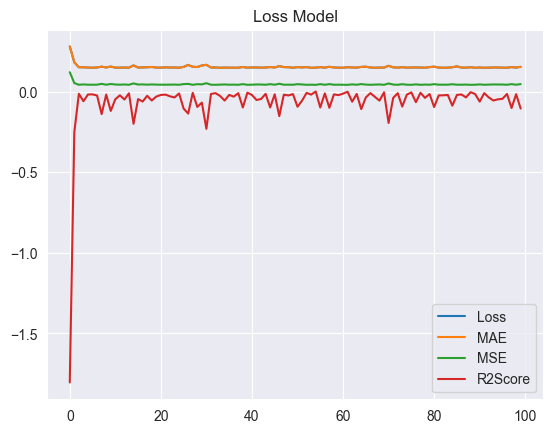

In [57]:
import matplotlib.pyplot as plt

plt.plot(model1_history.history["loss"])
plt.plot(model1_history.history["mae"])
plt.plot(model1_history.history["mse"])
plt.plot(model1_history.history["r2_score"])
plt.title("Loss Model")
plt.legend(["Loss", "MAE", "MSE", "R2Score"])
plt.show()

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_scaled = model1.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"Model 1 Evaluasi (Skala Asli):")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

5/5 [==============================] - 0s 6ms/step
Model 1 Evaluasi (Skala Asli):
MAE  : 6.1987
MSE  : 74.7360
RMSE : 8.6450
R²   : -0.0030


### Model with Dropout and BatchNormalization

In [59]:
model2 = Sequential([
    Dense(64, input_shape=(8,)),
    BatchNormalization(momentum=0.98),
    Dense(64, activation="relu"),

    Dense(32),
    BatchNormalization(momentum=0.98),
    Dropout(0.2),
    Dense(32, activation="relu"),

    Dense(16),
    BatchNormalization(momentum=0.98),
    Dropout(0.2),
    Dense(16, activation="relu"),

    Dense(8),
    BatchNormalization(momentum=0.98),
    Dropout(0.2),
    Dense(8, activation="relu"),

    Dense(1)
])

model2.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss="mae",
    metrics=["mae", "mse", R2Score()]
)

model2_history = model2.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
12/12 [==============================] - 4s 8ms/step - loss: 0.5050 - mae: 0.5050 - mse: 0.5843 - r2_score: -12.4621
Epoch 2/100
12/12 [==============================] - 0s 7ms/step - loss: 0.2782 - mae: 0.2782 - mse: 0.1479 - r2_score: -2.4080
Epoch 3/100
12/12 [==============================] - 0s 6ms/step - loss: 0.2093 - mae: 0.2093 - mse: 0.0700 - r2_score: -0.6130
Epoch 4/100
12/12 [==============================] - 0s 6ms/step - loss: 0.1940 - mae: 0.1940 - mse: 0.0656 - r2_score: -0.5110
Epoch 5/100
12/12 [==============================] - 0s 7ms/step - loss: 0.1831 - mae: 0.1831 - mse: 0.0642 - r2_score: -0.4785
Epoch 6/100
12/12 [==============================] - 0s 7ms/step - loss: 0.1762 - mae: 0.1762 - mse: 0.0557 - r2_score: -0.2834
Epoch 7/100
12/12 [==============================] - 0s 7ms/step - loss: 0.1716 - mae: 0.1716 - mse: 0.0529 - r2_score: -0.2181
Epoch 8/100
12/12 [==============================] - 0s 7ms/step - loss: 0.1633 - mae: 0.1633 - mse: 0.

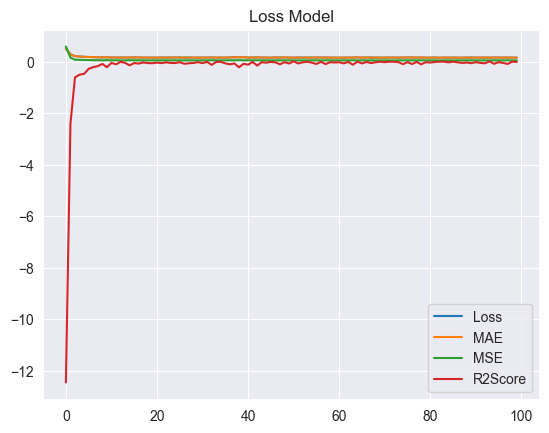

In [60]:
plt.plot(model2_history.history["loss"])
plt.plot(model2_history.history["mae"])
plt.plot(model2_history.history["mse"])
plt.plot(model2_history.history["r2_score"])
plt.title("Loss Model")
plt.legend(["Loss", "MAE", "MSE", "R2Score"])
plt.show()

In [61]:
y_pred_scaled = model2.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"Model 1 Evaluasi (Skala Asli):")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

5/5 [==============================] - 1s 11ms/step
Model 1 Evaluasi (Skala Asli):
MAE  : 6.1836
MSE  : 74.6852
RMSE : 8.6421
R²   : -0.0023


In [62]:
df.tail()

,crime_rate,nitrogen_oxides,room,age,distance,radial_highways,tax,lowes_status_population,medv
501,0.06263,0.573,6.593,69.1,2.4786,1,273,9.67,22.4
502,0.04527,0.573,6.120,76.7,2.2875,1,273,9.08,20.6
503,0.06076,0.573,6.976,91.0,2.1675,1,273,5.64,23.9
504,0.10959,0.573,6.794,89.3,2.3889,1,273,6.48,22.0
505,0.04741,0.573,6.030,80.8,2.5050,1,273,7.88,11.9


In [68]:
one_of_data = df.loc[505].drop("medv").values.reshape(1, -1)
one_of_data = scaler_X.transform(one_of_data)
one_of_data

array([[4.61841693e-04, 3.86831276e-01, 4.73079134e-01, 8.02265705e-01,
        1.25071611e-01, 0.00000000e+00, 1.64122137e-01, 1.69701987e-01]])

In [69]:
pred_model1 = model1.predict([one_of_data])

print("Predict model 1:")
print(pred_model1)

result_model1 = scaler_y.inverse_transform(pred_model1)
print(f"result redict model1 : {result_model1}")

1/1 [==============================] - 0s 64ms/step
Predict model 1:
[[0.37511235]]
result redict model1 : [[21.880056]]


In [70]:
pred_model2 = model2.predict(   [one_of_data])

print("Predict model 2:")
print(pred_model2)

result_model2 = scaler_y.inverse_transform(pred_model2)
print(f"result redict model2 : {result_model2}")

1/1 [==============================] - 0s 76ms/step
Predict model 2:
[[0.37383834]]
result redict model2 : [[21.822725]]
